# Laboratorio 7 - Deep Learning

- Juan Solís - 23720
- Victor Pérez - 23731
- Diego Flores - 23714

## Task 1

### Task 1.1

Se descarga el dataset ETTh1 y se construye el pipeline de preprocesamiento sobre la variable objetivo `OT` (Oil Temperature). Se normaliza con z-score guardando `mu` y `sigma`, se divide en bloques temporales contiguos 60/20/20 (train/val/test) y se generan ventanas deslizantes de longitud $L = 96$ para los horizontes $H \in \{24, 48\}$, donde $X^{(t)} = (x_{t-L+1}, \dots, x_t)$ y $y^{(t)} = x_{t+H}$.

In [7]:
import urllib.request
import numpy as np
import torch

URL = ("https://raw.githubusercontent.com/zhouhaoyi/"
       "ETDataset/main/ETT-small/ETTh1.csv")
urllib.request.urlretrieve(URL, "ETTh1.csv")

data = np.genfromtxt("ETTh1.csv", delimiter=",", skip_header=1)
OT  = data[:, -1].astype(np.float32)   # Oil Temperature: columna objetivo
ALL = data[:, 1:].astype(np.float32)   # 7 variables (6 de carga + OT)

# a. Normalizacion z-score de OT
mu, sigma = OT.mean(), OT.std()
OT_norm =torch.tensor((OT - mu) / sigma)

# b. Split temporal contiguo 60/20/20
n =len(OT_norm)
n_tr, n_vl =int(0.6 * n), int(0.8 * n)
OT_train, OT_val, OT_test = OT_norm[:n_tr], OT_norm[n_tr:n_vl],OT_norm[n_vl:]

# c. Ventanas deslizantes
def make_windows( series, L, H ):
    N = len(series) - L - H + 1
    X = torch.stack([series[i:i + L] for i in range(N)])
    y = series[L - 1 + H : L - 1 + H + N]
    return X, y

L=96
X_tr_24, y_tr_24 = make_windows(OT_train, L, 24)
X_vl_24, y_vl_24 = make_windows(OT_val, L, 24)
X_te_24, y_te_24 = make_windows(OT_test, L, 24)
X_tr_48, y_tr_48 = make_windows(OT_train, L, 48)
X_vl_48, y_vl_48 = make_windows(OT_val, L, 48)
X_te_48, y_te_48 = make_windows(OT_test, L, 48)

print(f"mu={mu:.4f}, sigma={sigma:.4f}")
print(f"Train: {len(OT_train)}, Val: {len(OT_val)}, Test: {len(OT_test)}")
print(f"X_tr_24: {tuple(X_tr_24.shape)}, X_tr_48: {tuple(X_tr_48.shape)}")

mu=13.3247, sigma=8.5667
Train: 10452, Val: 3484, Test: 3484
X_tr_24: (10333, 96), X_tr_48: (10309, 96)


### Task 1.2

Se implementa la función de autocorrelación (ACF) con la fórmula

$$\rho(k) = \frac{\frac{1}{N-k}\sum_{t=k}^{N-1}(x_t - \bar{x})(x_{t-k} - \bar{x})}{\frac{1}{N}\sum_{t=0}^{N-1}(x_t - \bar{x})^2}$$

y se calcula sobre el conjunto de entrenamiento hasta el lag 96. Se grafica el correlograma con las bandas de confianza al 95% en $\pm 1.96/\sqrt{N}$ y se identifican los picos para analizar la periodicidad de la serie y la elección de $L = 96$.

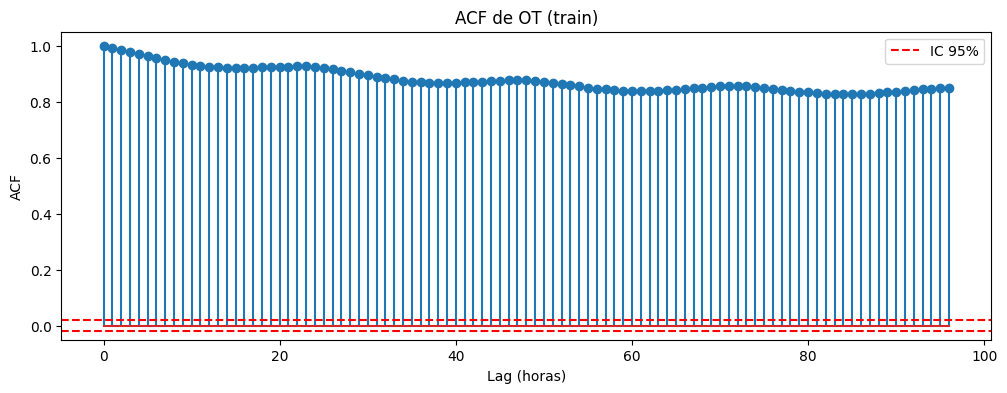

Picos locales: [(22, np.float32(0.9262)), (47, np.float32(0.877)), (72, np.float32(0.8572))]
rho(1) = 0.9923
rho(24) = 0.9250
rho(48) = 0.8763
rho(72) = 0.8572
rho(96) = 0.8489
IC 95%: +-0.0192


In [8]:
import matplotlib.pyplot as plt

# a. ACF manual segun la formula
def acf_manual(series, max_lag):
    N =len(series)
    d = series - series.mean()
    den =(d ** 2).sum() / N
    return np.array([(d[k:] * d[:N - k]).sum() / (N - k) / den for k in range(max_lag + 1)])

x_tr= OT_train.numpy()
acf_vals = acf_manual(x_tr, 96)
ci =1.96 / np.sqrt(len(x_tr))

plt.figure(figsize=(12, 4))
plt.stem(range(97), acf_vals)
plt.axhline(ci, color="r", linestyle="--", label="IC 95%")
plt.axhline(-ci, color="r", linestyle="--")
plt.xlabel("Lag (horas)")
plt.ylabel("ACF")
plt.title("ACF de OT (train)")
plt.legend()
plt.show()

# a. Picos locales de la ACF (despues del lag 0)
peaks =[k for k in range(1, 96) if acf_vals[k] > acf_vals[k - 1] and acf_vals[k] > acf_vals[k + 1]]
print( "Picos locales:", [ ( k, round( acf_vals[k],4 )) for k in peaks ] )

# b. Valores de la ACF en lags clave para justificar L = 96
for k in [1, 24, 48, 72, 96]:
    print(f"rho({k}) = {acf_vals[k]:.4f}")
print(f"IC 95%: +-{ci:.4f}")

In [9]:
# Ejecute esta celda para verificar su implementacion
_ok = True

# V1: split temporal correcto
assert len(OT_train) + len(OT_val) + len(OT_test) == len(OT_norm), \
    "Los splits no cubren toda la serie"
assert OT_train[-1] != OT_val[0], \
    "El ultimo valor de train no debe ser el primero de val"

# V2: ventanas correctas
assert X_tr_24.shape[1] == 96, f"Ventana incorrecta: {X_tr_24.shape[1]}"
assert y_tr_24.shape[0] == X_tr_24.shape[0], "X e y tienen distinto numero de ejemplos"

# V3: ACF en lag 24 (estacionalidad diaria esperada)
acf_lag24 = acf_manual(OT_train.numpy(), 48)[24]
assert 0.875 < acf_lag24 < 0.975, \
    f"ACF lag 24 fuera de rango: {acf_lag24:.4f} (esperado en [0.875, 0.975])"

# V4: baseline naive
naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
assert 0.15 < naive_mae < 0.25, \
    f"Naive MAE fuera de rango: {naive_mae:.4f} (esperado en [0.15, 0.25])"

print(f"Task 1: CORRECTO (ACF lag24={acf_lag24:.4f}, naive_mae={naive_mae:.4f})")

Task 1: CORRECTO (ACF lag24=0.9250, naive_mae=0.1996)


## Task 2

### Task 2.1

Se implementa la clase `LSTMForecaster` usando únicamente tensores de PyTorch y `nn.Parameter`, sin `nn.LSTM`. La celda LSTM se procesa manualmente paso a paso: en cada instante $t$ se calculan las compuertas $i, f, g, o$ a partir de $x_t$ y $h_{t-1}$, se actualiza el estado de celda $c_t = f \odot c_{t-1} + i \odot g$ y el estado oculto $h_t = o \odot \tanh(c_t)$. Al final, el último estado oculto $h_T$ se proyecta a un escalar que corresponde a la predicción (arquitectura many-to-one).

In [10]:
import torch.nn as nn
import torch.nn.functional as F

class LSTMForecaster(nn.Module):
    def __init__(self, d_in, d_h):
        super().__init__()
        self.d_h = d_h
        # SU CODIGO: declare los pesos de las 4 compuertas
        # Wx: (4*d_h, d_in), Wh: (4*d_h, d_h), b: (4*d_h,)
        # W_out: (1, d_h), b_out: (1,)
        # Use nn.Parameter para que sean aprendibles
        self.Wx =nn.Parameter( torch.randn(4 * d_h, d_in) * 0.1 )
        self.Wh= nn.Parameter(torch.randn(4 * d_h, d_h) * 0.1 )
        self.b= nn.Parameter(torch.zeros( 4 * d_h ) )
        self.W_out =nn.Parameter(torch.randn( 1, d_h ) * 0.1 )
        self.b_out =nn.Parameter( torch.zeros(1) )

    def forward(self, x):
        """
        Parametros
        ----------
        x : Tensor (B, L): batch de secuencias univariadas

        Retorna
        -------
        pred : Tensor (B,): prediccion escalar por secuencia

        Pasos:
        1. Reshape x a (B, L, 1) para procesarlo paso a paso
        2. Inicializar h y c en ceros: forma (B, d_h)
        3. Para cada paso t en range(L):
           a. Calcular gates = x[:,t,:] @ Wx.T + h @ Wh.T + b
           b. Separar en i, f, g, o de dimension d_h cada una
           c. Aplicar sigmoid a i, f, o y tanh a g
           d. Actualizar c = f*c + i*g
           e. Actualizar h = o*torch.tanh(c)
        4. Proyectar h_T con W_out: pred = h @ W_out.T + b_out
        5. Retornar pred.squeeze(-1)
        """
        # SU CODIGO AQUI
        x =x.unsqueeze(-1)
        B, L, _ = x.shape
        h= torch.zeros(B, self.d_h)
        c =torch.zeros(B, self.d_h)
        for t in range(L):
            gates = x[:, t, :] @ self.Wx.T + h @ self.Wh.T + self.b
            i, f, g, o = gates.chunk( 4, dim=-1)
            i, f, o =torch.sigmoid(i ), torch.sigmoid( f ), torch.sigmoid(o)
            g= torch.tanh(g )
            c =f * c + i * g
            h =o * torch.tanh( c)

        pred = h @ self.W_out.T + self.b_out
        return pred.squeeze(-1)

### Task 2.2

Se entrenan dos modelos `LSTMForecaster(d_in=1, d_h=32)`, uno para $H = 24$ y otro para $H = 48$, con Adam durante 20 épocas y `batch_size=64`, usando MSE como función de pérdida. 

Como el conjunto de validación está en un nivel de temperatura más bajo que casi todo el entrenamiento, cada ventana se expresa relativa a su último valor. El modelo recibe $X - x_t$, predice el cambio $y - x_t$ y luego se le suma $x_t$ de vuelta. Después se evalúa cada modelo en validación con MAE, RMSE y el ratio `MAE_modelo / MAE_naive`, donde el baseline naive predice el último valor observado de la ventana. 

Por último, se grafican las curvas de pérdida de entrenamiento de ambos horizontes.

Epoca 1/20 - loss: 0.1481
Epoca 2/20 - loss: 0.1417
Epoca 3/20 - loss: 0.1388
Epoca 4/20 - loss: 0.1389
Epoca 5/20 - loss: 0.1399
Epoca 6/20 - loss: 0.1400
Epoca 7/20 - loss: 0.1402
Epoca 8/20 - loss: 0.1401
Epoca 9/20 - loss: 0.1411
Epoca 10/20 - loss: 0.1435
Epoca 11/20 - loss: 0.1495
Epoca 12/20 - loss: 0.1489
Epoca 13/20 - loss: 0.1489
Epoca 14/20 - loss: 0.1477
Epoca 15/20 - loss: 0.1455
Epoca 16/20 - loss: 0.1478
Epoca 17/20 - loss: 0.1461
Epoca 18/20 - loss: 0.1438
Epoca 19/20 - loss: 0.1430
Epoca 20/20 - loss: 0.1401
Epoca 1/20 - loss: 0.2414
Epoca 2/20 - loss: 0.2146
Epoca 3/20 - loss: 0.2139
Epoca 4/20 - loss: 0.2071
Epoca 5/20 - loss: 0.2044
Epoca 6/20 - loss: 0.2008
Epoca 7/20 - loss: 0.2010
Epoca 8/20 - loss: 0.1990
Epoca 9/20 - loss: 0.2013
Epoca 10/20 - loss: 0.1992
Epoca 11/20 - loss: 0.1997
Epoca 12/20 - loss: 0.1998
Epoca 13/20 - loss: 0.1987
Epoca 14/20 - loss: 0.1993
Epoca 15/20 - loss: 0.1986
Epoca 16/20 - loss: 0.1982
Epoca 17/20 - loss: 0.1988
Epoca 18/20 - loss:

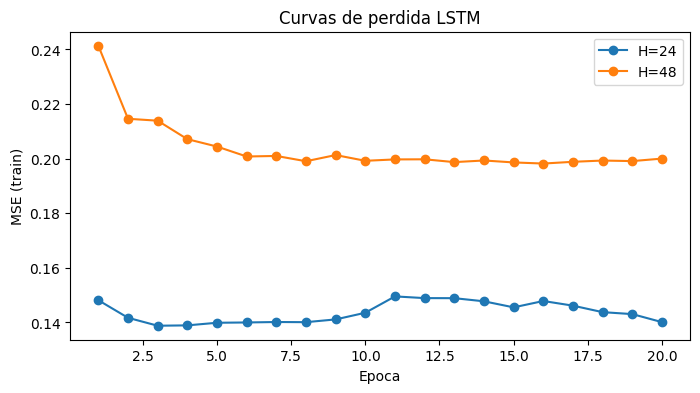

In [11]:
torch.manual_seed(42)

# a. Entrenamiento con Adam, 20 epocas, batch_size=64 y perdida MSE
def train_lstm(X, y, epochs=20, batch_size=64, lr=5e-4):
    model =LSTMForecaster(d_in=1, d_h=32)
    opt=torch.optim.Adam(model.parameters(), lr=lr)
    Xr, yr= X - X[:, -1:], y - X[:, -1]
    losses=[]

    for ep in range( epochs ):
        perm =torch.randperm(len( Xr))
        ep_loss= 0.0

        for k in range(0, len(Xr), batch_size ):
            idx = perm[k:k + batch_size]
            loss =F.mse_loss(model(Xr[idx]), yr[idx])
            opt.zero_grad()
            loss.backward()
            opt.step()
            ep_loss += loss.item() * len(idx)

        losses.append(ep_loss / len(Xr) )
        print(f"Epoca {ep+1}/{epochs} - loss: {losses[-1]:.4f}")

    return model, losses

def predict(model,X ):
    with torch.no_grad():
        return model(X - X[:, -1:]) + X[:, -1]

# b. Un modelo para H=24 y otro para H=48
lstm_24, losses_24= train_lstm(X_tr_24, y_tr_24)
lstm_48, losses_48 =train_lstm(X_tr_48, y_tr_48)

# c. Metricas en validacion: MAE, RMSE y ratio vs naive
pred_vl_24 =predict(lstm_24, X_vl_24)
pred_vl_48 =predict(lstm_48, X_vl_48)

for H, pred, X_vl, y_vl in [(24, pred_vl_24, X_vl_24, y_vl_24), (48, pred_vl_48, X_vl_48, y_vl_48)]:
    mae = torch.abs(y_vl - pred).mean().item()
    rmse = torch.sqrt(((y_vl - pred) ** 2).mean()).item()
    mae_naive = torch.abs(y_vl - X_vl[:, -1]).mean().item()
    print(f"LSTM H={H}: MAE={mae:.4f}, RMSE={rmse:.4f}, ratio={mae / mae_naive:.3f} (naive MAE={mae_naive:.4f})")

# d. Curvas de perdida de entrenamiento
plt.figure(figsize=(8, 4))
plt.plot(range(1, 21), losses_24, marker="o", label="H=24")
plt.plot(range(1, 21), losses_48, marker="o", label="H=48")
plt.xlabel("Epoca")
plt.ylabel("MSE (train)")
plt.title("Curvas de perdida LSTM")
plt.legend()
plt.show()

In [12]:
# Verificar shapes del forward
_model_test = LSTMForecaster(d_in=1, d_h=32)
_x_test = torch.randn(8, 96)
_pred_test = _model_test(_x_test)
assert _pred_test.shape == (8,), \
    f"Shape incorrecto: {_pred_test.shape} (esperado (8,))"

# Verificar que el modelo supera al naive en H=24
mae_lstm_24 = torch.abs(y_vl_24 - pred_vl_24).mean().item()
assert mae_lstm_24 < naive_mae * 1.1, \
    f"LSTM H=24 no supera al naive: {mae_lstm_24:.4f} vs {naive_mae:.4f}"

print(f"Task 2: CORRECTO")
print(f"  LSTM H=24: MAE={mae_lstm_24:.4f}, ratio={mae_lstm_24/naive_mae:.3f}")

Task 2: CORRECTO
  LSTM H=24: MAE=0.2023, ratio=1.013
